# 실습 내용

- 데이터 : mobile_cust_churn.csv
- Decision Tree 알고리즘으로 모델링한다.

# 1.환경 준비

In [21]:
# 라이브러리 불러오기
import warnings

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
warnings.filterwarnings('ignore')
%config InlineBackend.figure_format = 'retina'

In [22]:
# 데이터 읽어오기
path = 'data/mobile_cust_churn.csv'
df = pd.read_csv(path)

# 2.데이터 이해

In [23]:
# 상위 몇 개 행 확인
df.head()

,id,COLLEGE,INCOME,OVERAGE,LEFTOVER,HOUSE,HANDSET_PRICE,OVER_15MINS_CALLS_PER_MONTH,AVERAGE_CALL_DURATION,REPORTED_SATISFACTION,REPORTED_USAGE_LEVEL,CONSIDERING_CHANGE_OF_PLAN,CHURN
0,1,0,31953,0,6,313378,161,0,4,unsat,little,no,STAY
1,2,1,36147,0,13,800586,244,0,6,unsat,little,considering,STAY
2,3,1,27273,230,0,305049,201,16,15,unsat,very_little,perhaps,STAY
3,4,0,120070,38,33,788235,780,3,2,unsat,very_high,considering,LEAVE
4,5,1,29215,208,85,224784,241,21,1,very_unsat,little,never_thought,STAY


**데이터 설명**

- COLLEGE: 대학 졸업여부
- INCOME: 연수입
- OVERAGE: 월평균 초과사용 시간(분)
- LEFTOVER: 월평균 잔여시간비율(%)
- HOUSE: 집값
- HANDSET_PRICE: 스마트폰 가격
- OVER_15MINS_CALLS_PER_MONTH: 월평균 장기통화(15분이상) 횟수
- AVERAGE_CALL_DURATION: 평균 통화 시간
- REPORTED_SATISFACTION: 만족도 설문조사 결과
- REPORTED_USAGE_LEVEL: 사용도 자가진단 결과
- CONSIDERING_CHANGE_OF_PLAN: 향후 변경계획 설문조사 결과
- CHURN: 이탈(번호이동) 여부 (Target 변수)

In [24]:
# 변수 확인
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   id                           20000 non-null  int64
 1   COLLEGE                      20000 non-null  int64
 2   INCOME                       20000 non-null  int64
 3   OVERAGE                      20000 non-null  int64
 4   LEFTOVER                     20000 non-null  int64
 5   HOUSE                        20000 non-null  int64
 6   HANDSET_PRICE                20000 non-null  int64
 7   OVER_15MINS_CALLS_PER_MONTH  20000 non-null  int64
 8   AVERAGE_CALL_DURATION        20000 non-null  int64
 9   REPORTED_SATISFACTION        20000 non-null  str  
 10  REPORTED_USAGE_LEVEL         20000 non-null  str  
 11  CONSIDERING_CHANGE_OF_PLAN   20000 non-null  str  
 12  CHURN                        20000 non-null  str  
dtypes: int64(9), str(4)
memory usage: 2.0 MB


In [25]:
df.describe()

,id,COLLEGE,INCOME,OVERAGE,LEFTOVER,HOUSE,HANDSET_PRICE,OVER_15MINS_CALLS_PER_MONTH,AVERAGE_CALL_DURATION
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,10000.500000,0.502400,80281.447750,85.979550,23.898650,493155.264250,389.615100,8.000700,6.002250
std,5773.647028,0.500007,41680.586319,85.992324,26.816645,252407.884692,213.820682,8.925418,4.402558
min,1.000000,0.000000,20007.000000,-2.000000,0.000000,150002.000000,130.000000,0.000000,1.000000
25%,5000.750000,0.000000,42217.000000,0.000000,0.000000,263714.250000,219.000000,1.000000,2.000000
50%,10000.500000,1.000000,75366.500000,59.000000,14.000000,452259.500000,326.000000,4.000000,5.000000
75%,15000.250000,1.000000,115881.750000,179.000000,41.000000,702378.000000,533.250000,15.000000,10.000000
max,20000.000000,1.000000,159983.000000,335.000000,89.000000,999996.000000,899.000000,29.000000,15.000000


In [26]:
# target 값 개수 확인
df['CHURN'].value_counts()

CHURN
STAY     10148
LEAVE     9852
Name: count, dtype: int64

In [27]:
# 상관관계 확인
df.corr(numeric_only=True)

,id,COLLEGE,INCOME,OVERAGE,LEFTOVER,HOUSE,HANDSET_PRICE,OVER_15MINS_CALLS_PER_MONTH,AVERAGE_CALL_DURATION
id,1.000000,-0.005557,0.003686,-0.006050,0.006069,0.011347,-0.007838,0.001254,-0.005830
COLLEGE,-0.005557,1.000000,0.011122,-0.003091,-0.003925,-0.000217,0.009950,-0.007205,-0.001490
INCOME,0.003686,0.011122,1.000000,0.000458,0.006515,-0.010964,0.727200,0.002136,-0.007219
OVERAGE,-0.006050,-0.003091,0.000458,1.000000,-0.003123,0.002412,0.000324,0.770557,0.000653
LEFTOVER,0.006069,-0.003925,0.006515,-0.003123,1.000000,0.006530,0.004004,-0.010411,-0.660285
HOUSE,0.011347,-0.000217,-0.010964,0.002412,0.006530,1.000000,-0.007756,0.007410,-0.009359
HANDSET_PRICE,-0.007838,0.009950,0.727200,0.000324,0.004004,-0.007756,1.000000,0.002680,-0.005190
OVER_15MINS_CALLS_PER_MONTH,0.001254,-0.007205,0.002136,0.770557,-0.010411,0.007410,0.002680,1.000000,0.007769
AVERAGE_CALL_DURATION,-0.005830,-0.001490,-0.007219,0.000653,-0.660285,-0.009359,-0.005190,0.007769,1.000000


# 3.데이터 전처리

**1) 변수 제거**

In [28]:
# 제거 대상: id
drop_cols = ['id']

# 변수 제거
df.drop(drop_cols, axis=1, inplace=True)
# 확인
df.head()

,COLLEGE,INCOME,OVERAGE,LEFTOVER,HOUSE,HANDSET_PRICE,OVER_15MINS_CALLS_PER_MONTH,AVERAGE_CALL_DURATION,REPORTED_SATISFACTION,REPORTED_USAGE_LEVEL,CONSIDERING_CHANGE_OF_PLAN,CHURN
0,0,31953,0,6,313378,161,0,4,unsat,little,no,STAY
1,1,36147,0,13,800586,244,0,6,unsat,little,considering,STAY
2,1,27273,230,0,305049,201,16,15,unsat,very_little,perhaps,STAY
3,0,120070,38,33,788235,780,3,2,unsat,very_high,considering,LEAVE
4,1,29215,208,85,224784,241,21,1,very_unsat,little,never_thought,STAY


**2) x, y 분리**

In [29]:
# Target 설정
target = 'CHURN'

# 데이터 분리
X = df.drop(target, axis=1)
y = df[target]

**3) 가변수화**

In [30]:
# 가변수화 대상: REPORTED_SATISFACTION, REPORTED_USAGE_LEVEL, CONSIDERING_CHANGE_OF_PLAN
df_dummies = ['REPORTED_SATISFACTION', 'REPORTED_USAGE_LEVEL', 'CONSIDERING_CHANGE_OF_PLAN']

# 가변수화
X = pd.get_dummies(X, columns=df_dummies, drop_first=True)

# 확인
X.head()

,COLLEGE,INCOME,OVERAGE,LEFTOVER,HOUSE,HANDSET_PRICE,OVER_15MINS_CALLS_PER_MONTH,AVERAGE_CALL_DURATION,REPORTED_SATISFACTION_sat,REPORTED_SATISFACTION_unsat,REPORTED_SATISFACTION_very_sat,REPORTED_SATISFACTION_very_unsat,REPORTED_USAGE_LEVEL_high,REPORTED_USAGE_LEVEL_little,REPORTED_USAGE_LEVEL_very_high,REPORTED_USAGE_LEVEL_very_little,CONSIDERING_CHANGE_OF_PLAN_considering,CONSIDERING_CHANGE_OF_PLAN_never_thought,CONSIDERING_CHANGE_OF_PLAN_no,CONSIDERING_CHANGE_OF_PLAN_perhaps
0,0,31953,0,6,313378,161,0,4,False,True,False,False,False,True,False,False,False,False,True,False
1,1,36147,0,13,800586,244,0,6,False,True,False,False,False,True,False,False,True,False,False,False
2,1,27273,230,0,305049,201,16,15,False,True,False,False,False,False,False,True,False,False,False,True
3,0,120070,38,33,788235,780,3,2,False,True,False,False,False,False,True,False,True,False,False,False
4,1,29215,208,85,224784,241,21,1,False,False,False,True,False,True,False,False,False,True,False,False


**4) 학습용, 평가용 데이터 분리**

In [31]:
# 모듈 불러오기
from sklearn.model_selection import train_test_split

# 7:3으로 분리
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.3,
                                                    random_state=1
                                                    )

# 4.모델링

In [32]:
# 1단계: 불러오기
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix


In [33]:
# 2단계: 선언하기
model = DecisionTreeClassifier()

In [34]:
# 3단계: 학습하기
model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [35]:
# 4단계: 예측하기
y_pred = model.predict(X_test)

In [36]:
# 5단계: 평가하기
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


              precision    recall  f1-score   support

       LEAVE       0.61      0.63      0.62      2935
        STAY       0.63      0.62      0.63      3065

    accuracy                           0.62      6000
   macro avg       0.62      0.62      0.62      6000
weighted avg       0.62      0.62      0.62      6000

[[1840 1095]
 [1168 1897]]


# 5.기타

- 기타 필요한 내용이 있으면 진행합니다.

In [37]:
# 트리 시각화
# 시각화 모듈 불러오기
from sklearn.tree import export_graphviz
from IPython.display import Image

In [38]:
# 이미지 파일 만들기
export_graphviz(model,                              # 학습된 결정 트리 모델
                out_file='tree2.dot',                # 저장할 파일
                feature_names=X.columns,             # Feature(입력변수) 이름 지정
                class_names=['yes_churn', 'no_churn'],    # Target 클래스 이름
                rounded=True,                       # 노드를 둥근 사각형
                precision=2,                        # 소수점 2자리까지
                max_depth=5,
                filled=True)                        # 노드 내부 색상 채우기


In [ ]:
get_ipython().system('dot tree2.dot -Tpng -otree2.png -Gdpi=300')
Image(filename='tree2.png')


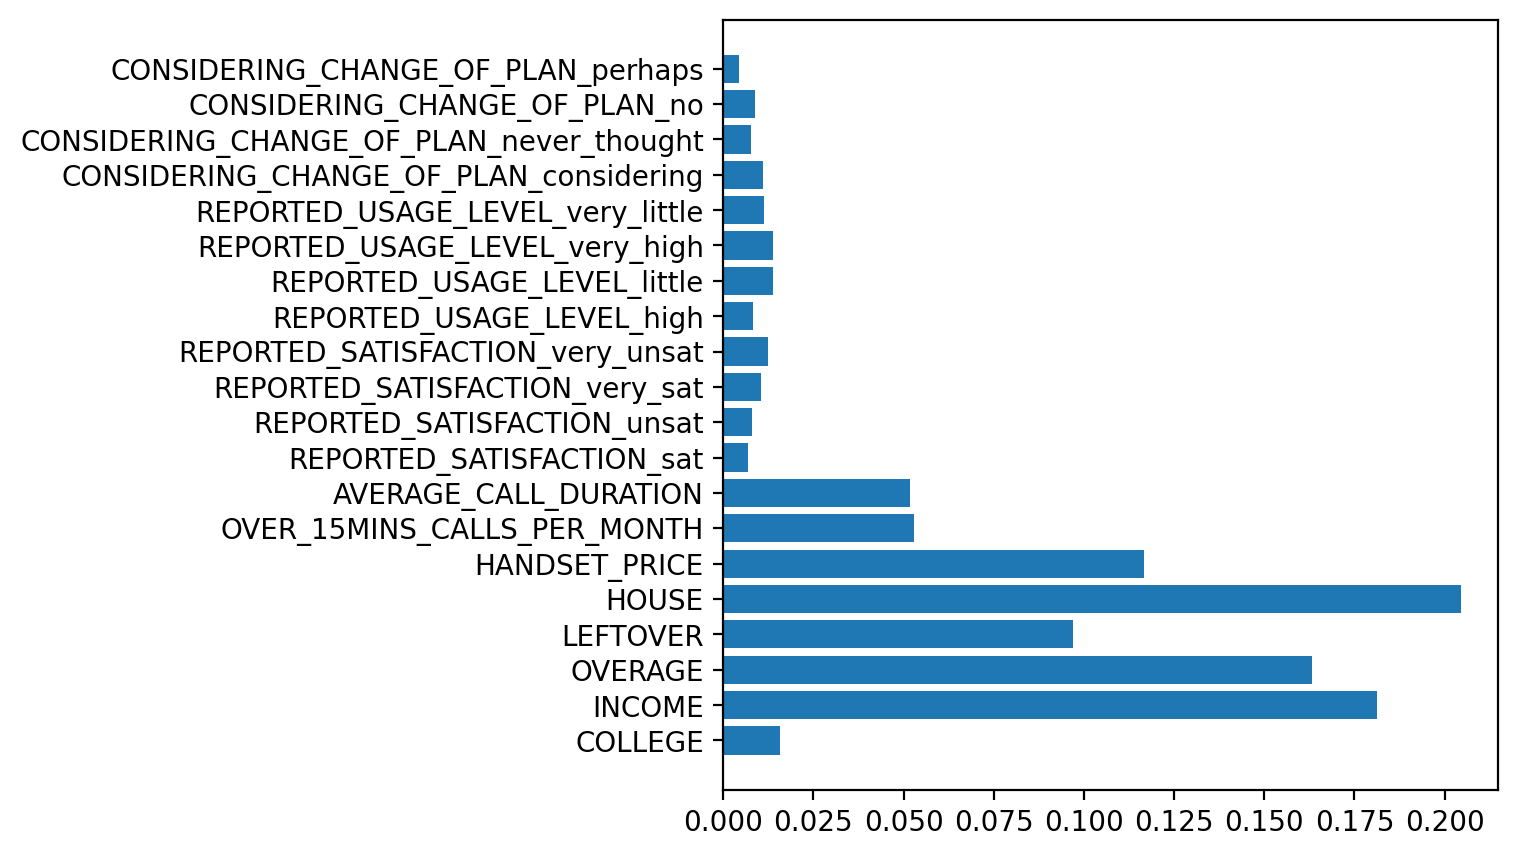

In [41]:
# 변수 중요도 시각화
plt.figure(figsize=(5,5))
plt.barh(list(X), model.feature_importances_)
plt.show()


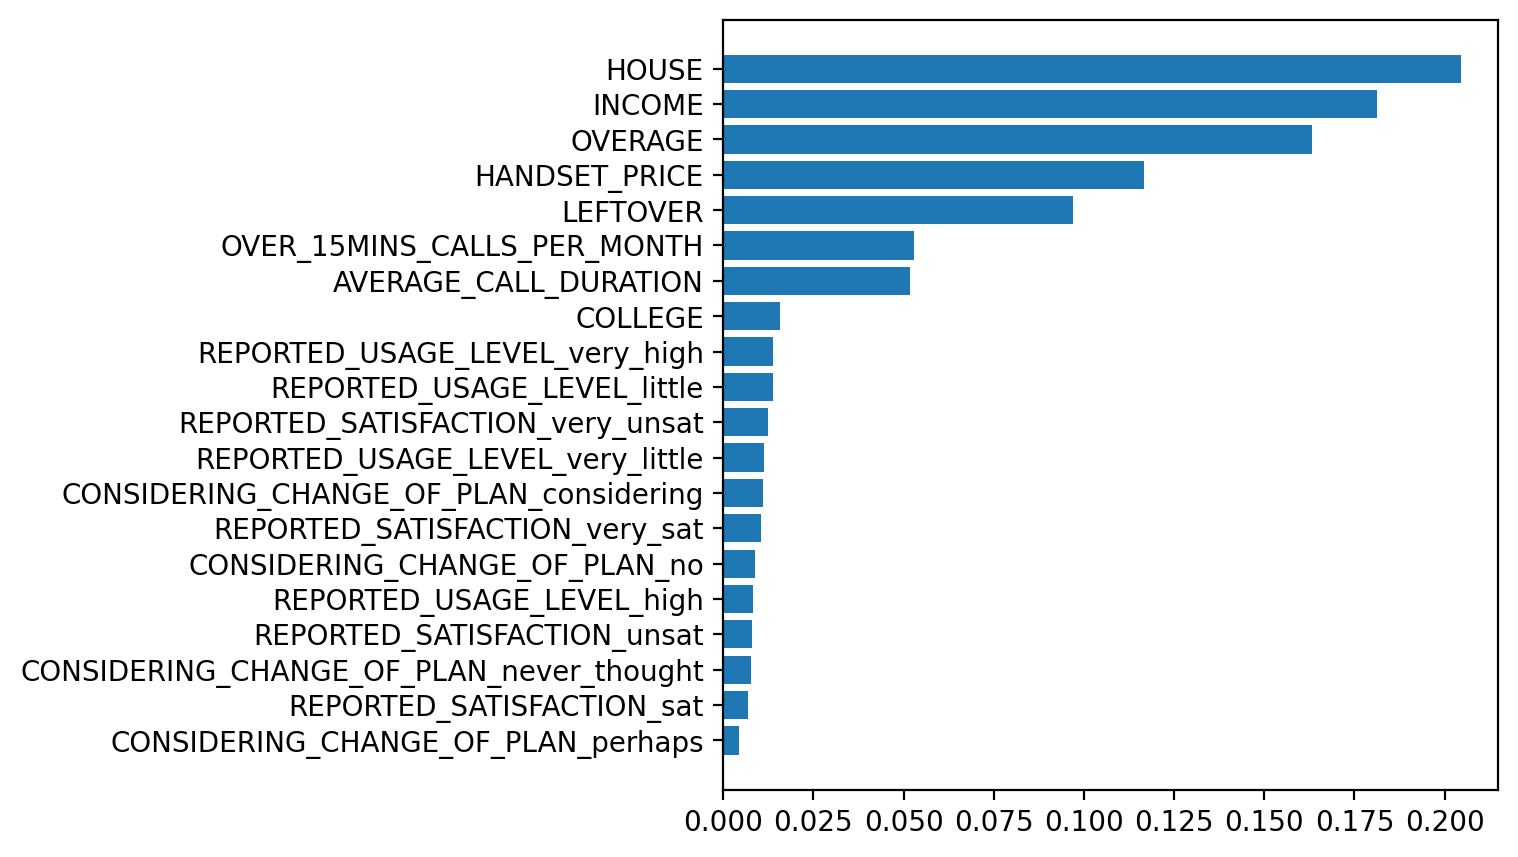

In [42]:
df_im = pd.DataFrame()
df_im['feature'] = list(X)
df_im['importance'] = model.feature_importances_
df_im.sort_values(by = 'importance', ascending=True, inplace=True)

plt.figure(figsize=(5,5))
plt.barh(df_im['feature'], df_im['importance'])
plt.show()